## EEG-Based Classification of Major Depressive Disorder (MDD)

## Objective 
Build machine learning models to classify MDD vs healthy controls using EEG data

## Planned workflow
1. Inspect dataset structure and metadata
2. Define patient-level splits
3. Preprocess EEG recordings
4. Extract features
5. Train baseline models
6. Compare performance across conditions
7. Add and advanced extension 

### Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path 
import mne

from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix, 
    ConfusionMatrixDisplay
)
from sklearn.base import clone

### Project paths

In [3]:
def find_project_root():
    p = Path.cwd()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
    raise FileNotFoundError("Project root (with .git) not found")

PROJECT_ROOT = find_project_root()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "nm000114"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed_features"
RESULTS_DIR = PROJECT_ROOT / "results"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DATA_DIR:", RAW_DATA_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

PROJECT_ROOT: d:\eeg-mdd-classification
RAW_DATA_DIR: d:\eeg-mdd-classification\data\raw\nm000114
PROCESSED_DIR: d:\eeg-mdd-classification\data\processed_features
RESULTS_DIR: d:\eeg-mdd-classification\results


In [4]:
# Helper function to load a single EDF file and return the raw data object

def get_eeg_file(subject_id: str, condition: str):
    return RAW_DATA_DIR / subject_id / "eeg" / f"{subject_id}_task-{condition}_eeg.edf"

In [5]:
# Test loading one file to ensure everything is working correctly

file_path = get_eeg_file("sub-HS1", "P300")

print(file_path)
print(file_path.exists())

raw = mne.io.read_raw_edf(file_path, preload=True)
print(raw)

d:\eeg-mdd-classification\data\raw\nm000114\sub-HS1\eeg\sub-HS1_task-P300_eeg.edf
True
Extracting EDF parameters from d:\eeg-mdd-classification\data\raw\nm000114\sub-HS1\eeg\sub-HS1_task-P300_eeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 154879  =      0.000 ...   604.996 secs...
<RawEDF | sub-HS1_task-P300_eeg.edf, 22 x 154880 (605.0 s), ~26.0 MiB, data loaded>


In [6]:
# Scan all files in the raw data directory to ensure we can access them

edf_files = sorted(RAW_DATA_DIR.glob("sub-*/*/*.edf"))

print(f"Number of EDF files found:", len(edf_files))
for file in edf_files[:5]:
    print(file)

Number of EDF files found: 181
d:\eeg-mdd-classification\data\raw\nm000114\sub-HS1\eeg\sub-HS1_task-eyesClosed_eeg.edf
d:\eeg-mdd-classification\data\raw\nm000114\sub-HS1\eeg\sub-HS1_task-eyesOpen_eeg.edf
d:\eeg-mdd-classification\data\raw\nm000114\sub-HS1\eeg\sub-HS1_task-P300_eeg.edf
d:\eeg-mdd-classification\data\raw\nm000114\sub-HS10\eeg\sub-HS10_task-eyesClosed_eeg.edf
d:\eeg-mdd-classification\data\raw\nm000114\sub-HS10\eeg\sub-HS10_task-eyesOpen_eeg.edf


In [7]:
# Parser cell to read all EDF files and extract data and labels for modeling

def infer_label_from_subject(subject_id: str) -> int:
    """
    Infer the label (0 or 1) from the subject ID.
    returns: 
        0 for healthy controls (sub-HS*)
        1 for MDD patients (sub-MDD*)
    """
    subject_upper = subject_id.upper()
    if "HS" in subject_upper:
        return 0
    elif "MDD" in subject_upper:
        return 1 
    else: 
        raise ValueError(f"Could not infer label from subject ID: {subject_id}")
    
def parse_condition_from_filename(filepath: Path) -> str:
    """
    Parse the condition from the filename
    Returns:
        - eyesClosed
        - eyesOpen
        - P300
    """

    name = filepath.name 
    if "task-eyesClosed" in name:
        return "eyesClosed"
    elif "task-eyesOpen" in name:
        return "eyesOpen"
    elif "task-P300" in name:
        return "P300"
    else:
        raise ValueError(f"Could not parse condition from filename: {name}")
        

In [8]:
# metadata list to hold all parsed information 

rows = []

for filepath in edf_files:
    subject_id = filepath.parts[-3]  # e.g. subHS1
    condition = parse_condition_from_filename(filepath)
    label = infer_label_from_subject(subject_id)

    rows.append({
        "patient_id": subject_id,
        "recording_id": filepath.stem,
        "label": label,
        "condition": condition,
        "filepath": str(filepath),
    })


# Create a DataFrame from the metadata
metadata_df = pd.DataFrame(rows)

print(metadata_df.head())
print("\nShape:", metadata_df.shape)
print("\nPatients:", metadata_df["patient_id"].nunique())
print("\nClass counts:")
print(metadata_df["label"].value_counts())
print("\nCondition counts:")
print(metadata_df["condition"].value_counts())
print(metadata_df.groupby("patient_id").size().value_counts())

  patient_id                  recording_id  label   condition  \
0    sub-HS1   sub-HS1_task-eyesClosed_eeg      0  eyesClosed   
1    sub-HS1     sub-HS1_task-eyesOpen_eeg      0    eyesOpen   
2    sub-HS1         sub-HS1_task-P300_eeg      0        P300   
3   sub-HS10  sub-HS10_task-eyesClosed_eeg      0  eyesClosed   
4   sub-HS10    sub-HS10_task-eyesOpen_eeg      0    eyesOpen   

                                            filepath  
0  d:\eeg-mdd-classification\data\raw\nm000114\su...  
1  d:\eeg-mdd-classification\data\raw\nm000114\su...  
2  d:\eeg-mdd-classification\data\raw\nm000114\su...  
3  d:\eeg-mdd-classification\data\raw\nm000114\su...  
4  d:\eeg-mdd-classification\data\raw\nm000114\su...  

Shape: (181, 5)

Patients: 64

Class counts:
label
1    95
0    86
Name: count, dtype: int64

Condition counts:
condition
eyesOpen      62
P300          61
eyesClosed    58
Name: count, dtype: int64
3    52
2    10
4     1
1     1
Name: count, dtype: int64


In [9]:
# save metadata to CSV for future reference
metadata_path = PROJECT_ROOT / "data" / "processed_features" / "metadata.csv"
metadata_df.to_csv(metadata_path, index=False)
print("Saved metadata to:", metadata_path)

Saved metadata to: d:\eeg-mdd-classification\data\processed_features\metadata.csv


In [10]:
debug_rows = []

for _, row in metadata_df.iterrows():
    raw = mne.io.read_raw_edf(row["filepath"], preload=False, verbose=False)
    debug_rows.append({
        "patient_id": row["patient_id"],
        "condition": row["condition"],
        "filepath": row["filepath"],
        "n_channels": len(raw.ch_names),
        "channel_names": raw.ch_names
    })

debug_df = pd.DataFrame(debug_rows)

print(debug_df["n_channels"].value_counts())


n_channels
22    112
20     69
Name: count, dtype: int64


In [11]:
print("20-channel example:")
print(debug_df.loc[debug_df["n_channels"] == 20, "channel_names"].iloc[0])

print("\n22-channel example:")
print(debug_df.loc[debug_df["n_channels"] == 22, "channel_names"].iloc[0])


20-channel example:
['EEG Fp1-LE', 'EEG F3-LE', 'EEG C3-LE', 'EEG P3-LE', 'EEG O1-LE', 'EEG F7-LE', 'EEG T3-LE', 'EEG T5-LE', 'EEG Fz-LE', 'EEG Fp2-LE', 'EEG F4-LE', 'EEG C4-LE', 'EEG P4-LE', 'EEG O2-LE', 'EEG F8-LE', 'EEG T4-LE', 'EEG T6-LE', 'EEG Cz-LE', 'EEG Pz-LE', 'EEG A2-A1']

22-channel example:
['EEG Fp1-LE', 'EEG F3-LE', 'EEG C3-LE', 'EEG P3-LE', 'EEG O1-LE', 'EEG F7-LE', 'EEG T3-LE', 'EEG T5-LE', 'EEG Fz-LE', 'EEG Fp2-LE', 'EEG F4-LE', 'EEG C4-LE', 'EEG P4-LE', 'EEG O2-LE', 'EEG F8-LE', 'EEG T4-LE', 'EEG T6-LE', 'EEG Cz-LE', 'EEG Pz-LE', 'EEG A2-A1', 'EEG 23A-23R', 'EEG 24A-24R']


In [12]:
COMMON_CHANNELS = [
'EEG Fp1-LE', 'EEG F3-LE', 'EEG C3-LE', 'EEG P3-LE', 'EEG O1-LE',
 'EEG F7-LE', 'EEG T3-LE', 'EEG T5-LE', 'EEG Fz-LE', 'EEG Fp2-LE', 
 'EEG F4-LE', 'EEG C4-LE', 'EEG P4-LE', 'EEG O2-LE', 'EEG F8-LE', 
 'EEG T4-LE', 'EEG T6-LE', 'EEG Cz-LE', 'EEG Pz-LE', 'EEG A2-A1'
]

print("Number of common channels:", len(COMMON_CHANNELS))



Number of common channels: 20


In [13]:
# Step 1: Extract spectral features (e.g. power in different frequency bands) from each EEG recording

def extract_band_power(raw, COMMON_CHANNELS) -> np.ndarray:
    """
    Extract basic EEG band power features from the raw MNE objects.
    Returns a feature vector.
    """

    data_raw = raw.copy()
    data_raw.pick(COMMON_CHANNELS)
    
    # get data 
    data = data_raw.get_data()      # shape: (n_channels, n_time points)
    sfreq = data_raw.info['sfreq']  # sampling frequency (e.g. 256 Hz)

    # Define frequency bands 
    bands = {
        "delta": (1, 4),     # deep sleep
        "theta": (4, 8),     # drowsiness
        "alpha": (8, 13),    # relaxed 
        "beta":  (13, 30)    # active thinking 
    }

    all_features = []

    # Loop through each channel (ch) and convert signal to frequency domain using Welch's method to estimate power spectral density (psd)
    for ch in data:        
        psd, freqs = mne.time_frequency.psd_array_welch(
            ch,
            sfreq=sfreq,
            fmin=1,
            fmax=30,
            verbose=False
        )

        total_power = psd.sum()
        
        band_features = [
            (
                psd[(freqs >= fmin) & (freqs <= fmax)].mean()
            / total_power                                      # normalize by total power to get relative power in each band
            if total_power > 0 else 0                          # handle case where total power is zero to avoid division by zero
            )                           
            for (fmin, fmax) in bands.values()
            ]
    
        all_features.append(band_features)

    return np.nan_to_num(np.array(all_features).flatten())



In [14]:
# Build feature matrix 

records = [
    (
        extract_band_power(
            mne.io.read_raw_edf(row["filepath"], preload=True, verbose=False),
            COMMON_CHANNELS
        ),
        row["label"],
        row["patient_id"]
    )
    for _, row in metadata_df.iterrows()
]

X = np.vstack([r[0] for r in records])
y = np.array([r[1] for r in records])
groups = np.array([r[2] for r in records])

print("X.shape:", X.shape)
print("y.shape:", y.shape)
print("Groups shape:", groups.shape)


X.shape: (181, 80)
y.shape: (181,)
Groups shape: (181,)


## GroupKFold 

Regular K-fold can accidentally put recordings from the same patient in both train and test sets. 
GroupKfold ensures that all recordings from the same patient are in the same fold, preventing data leakage and splits happen at the patient level. 

## Cross- Validation evaluation of model 

Accuracy measures overall correctness

accuracy = (# correct predictions) / (total)

F1 Score looks at balance of precision and recall
- True positive (TP) - correctly predicted MDD
- False positive (FP) - predicted MDD but actually healthy 
- False negative (FN) - missed MD (predicted healthy)

Precision = TP / (TP + FP)

Recall = TP / (TP + FN)

F1 = 2 x (precision x recall) / (precision + recall)

High F1 = model 
- finds MDD patients
- doesnt over-predict MDD

ROC-AUC = probability model ranks MDD higher than healthy 

ROC-AUC considers all thresholds and can plot True positive rate (TPR) vs False positive rate(FPR)

Overall - evaluates how well the model separates classes across thresholds


In [15]:

# create the splitter, five folds total 
gfk = GroupKFold(n_splits=5)

# build a baseline pipeline with standard scaling and logistic regression 
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])


# evaluate the pipeline using cross-validation 
results_lr = cross_validate(
    pipeline, 
    X, 
    y,
    cv=gfk.split(X, y, groups=groups),
    scoring=["accuracy", "f1", "roc_auc"]
)

print("Accuracy:", results_lr["test_accuracy"])
print("Mean accuracy:", results_lr["test_accuracy"].mean())
print("Std accuracy:", results_lr["test_accuracy"].std())

print("F1 score:", results_lr["test_f1"])
print("Mean F1 score:", results_lr["test_f1"].mean())

print("ROC-AUC:", results_lr["test_roc_auc"])
print("Mean ROC-AUC:", results_lr["test_roc_auc"].mean())


Accuracy: [0.72972973 0.67567568 0.80555556 0.68571429 0.91666667]
Mean accuracy: 0.7626683826683827
Std accuracy: 0.0895872759246791
F1 score: [0.66666667 0.72727273 0.82926829 0.7027027  0.93333333]
Mean F1 score: 0.7718487445316713
ROC-AUC: [0.81677019 0.79503106 0.81587302 0.80333333 0.96753247]
Mean ROC-AUC: 0.8397080117949682


In [16]:
# test to ensure that there is no data leakage 
# by checking that all samples from the same patient are in the same fold

for fold, (train_idx, test_idx) in enumerate(gfk.split(X, y, groups), start=1):
    train_groups = set(groups[train_idx])
    test_groups = set(groups[test_idx])
    overlap = train_groups.intersection(test_groups)

    assert len(overlap) == 0, f"Data leakage detected in fold {fold}! Overlapping groups: {overlap}"
print("No data leakage detected across folds!")

No data leakage detected across folds!


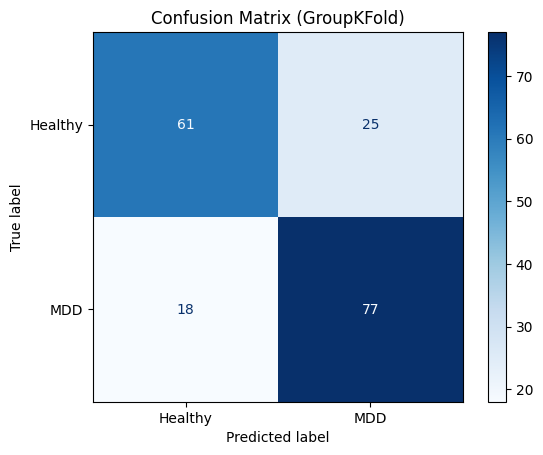

In [17]:
# confusion matrix 

from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(
    pipeline, 
    X,
    y,
    cv=gfk.split(X, y, groups)
)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "MDD"])

disp.plot(cmap=plt.cm.Blues, values_format="d")
plt.title("Confusion Matrix (GroupKFold)")
plt.show()

## Discussion:

accuracy: (61 + 77) / 181 = 138 / 181 = 0.762

recall: 77 / (77 + 18) = 0.81
 
precision: 77 / ( 77 + 52) = 0.755

The Confusion matrix shows that the model achieves approximately 76% accuracy. Importantly, the model demonstrates strong sensitivity to MDD cases, correctly identifying ~81% of patients with depression. However, the model exhibits a moderate false positive, misclassifying 25 healthy subjects as MDD. This suggests a slight bias toward predicting the positive class, which may be preferable in clinical contexts where missing true MDD cases is more critical than over-diagnosis. 

In [18]:
# Run cross-validation with SVM

pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf",probability=True)
     )
])

results_svm = cross_validate(
    pipeline_svm,
    X,
    y,
    cv=gfk.split(X, y, groups),
    scoring=["accuracy", "f1", "roc_auc"]
)

print("SVM accuracy:", results_svm["test_accuracy"])
print("SVM mean accuracy:", results_svm["test_accuracy"].mean())
print("SVM std accuracy:", results_svm["test_accuracy"].std())

print("SVM F1 score:", results_svm["test_f1"])
print("SVM mean F1 score:", results_svm["test_f1"].mean())  

print("SVM ROC-AUC:", results_svm["test_roc_auc"])
print("SVM mean ROC-AUC:", results_svm["test_roc_auc"].mean())


SVM accuracy: [0.83783784 0.67567568 0.75       0.74285714 0.94444444]
SVM mean accuracy: 0.7901630201630201
SVM std accuracy: 0.09277274641045152
SVM F1 score: [0.8125     0.72727273 0.80851064 0.75675676 0.95652174]
SVM mean F1 score: 0.8123123722915582
SVM ROC-AUC: [0.88198758 0.73602484 0.9047619  0.83666667 0.98051948]
SVM mean ROC-AUC: 0.86799209486166


In [19]:
# Direct comparison of logistic regression vs SVM using paired t-test on cross-validation results

comparison_df = pd.DataFrame({
    "Model": ["LogisticRegression", "SVM"],
    "Accuracy": [results_lr["test_accuracy"].mean(), results_svm["test_accuracy"].mean()],
    "F1 Score": [results_lr["test_f1"].mean(), results_svm["test_f1"].mean()],
    "ROC-AUC": [results_lr["test_roc_auc"].mean(), results_svm["test_roc_auc"].mean()]
})

print(comparison_df)


                Model  Accuracy  F1 Score   ROC-AUC
0  LogisticRegression  0.762668  0.771849  0.839708
1                 SVM  0.790163  0.812312  0.867992


SVM > Logistic Regression across all metrics 

Quantitatively:
- +2.7% accuracy gain 
- +4% F1 improvement 
- +0.03 ROC-AUC improvement  


EEG signal is not purely linear and benefits from nonlinear modeling.

## Condition specific analysis
 
Goal: which EEG condition (eyes closed, eyes open, P300) provides the 
most discriminative power for classifying MDD vs healthy controls?


In [20]:

# filter by condition 

def run_condition_model(condition_name):
    mask = metadata_df["condition"] == condition_name

    X_cond = X[mask]
    y_cond = y[mask]
    groups_cond = groups[mask]

    results = cross_validate(
        pipeline,
        X_cond,
        y_cond, 
        cv=GroupKFold(n_splits=5).split(X_cond, y_cond, groups_cond),
        scoring=["accuracy", "f1", "roc_auc"]
    )

    return {
        "Condition": condition_name,
        "Accuracy": results["test_accuracy"].mean(),
        "F1": results["test_f1"].mean(),
        "Roc-Auc": results["test_roc_auc"].mean()
    }



In [21]:
# Run all conditions 

conditions = ["eyesClosed", "eyesOpen", "P300"]

results = [run_condition_model(cond) for cond in conditions]

pd.DataFrame(results)

,Condition,Accuracy,F1,Roc-Auc
0,eyesClosed,0.780303,0.762797,0.853333
1,eyesOpen,0.707692,0.716725,0.817460
2,P300,0.819231,0.845275,0.852381


Discussion: 

P300 is the best condition.
- highest accuracy 
- highest F1 
- strong ROC-AUC 

eyesClosed - second best 
- slightly lower accuracy than p300
- highest ROC-AUC 
- good general separability, but weaker classification than p300

eyesOpen - the weakest 
- lowest across all metrics 
- least informative condition for MDD classification 


P300:

- event-related potential 
- tied to cognitive processing/ attention 

MDD affects:
- attention
- cognitive response timing 
- neural preprocessing 

P300 captures disease-related signal more directly 


Among the three EEG conditions, the P300 task produced the strongest classification performance, achieving the highest accuracy (0.82) and F1 score (0.85). This suggests that task-evoked neural responses provide more discriminitative information for identifying MDD compared to resting-state conditions. The eyesClosed condition performed moderately well, while eyesOpen consitently yielded the weakest performance, likely due to increased variability and reduced signal structure. 


## Augmentation experiment

In [ ]:
# Apply Augmentation to P300 only subset to test if we can get better performance by focusing on the condition that is most relevant to MDD diagnosis 

p300_mask = metadata_df['condition'] == "P300"

X_p300 = X[p300_mask]
y_p300 = y[p300_mask]
groups_p300 = groups[p300_mask]

print("X_p300 shape:", X_p300.shape)
print("y_p300 shape:", y_p300.shape)
print("unique patients:", len(np.unique(groups_p300)))

X_p300 shape: (61, 80)
y_p300 shape: (61,)
unique patients: 61


In [41]:
# Run Baseline SVM on P300 only subset 

gfk = GroupKFold(n_splits=5)

baseline_p300 = cross_validate(
    pipeline_svm,
    X_p300,
    y_p300,
    cv=gfk.split(X_p300, y_p300, groups=groups_p300),
    scoring=["accuracy", "f1", "roc_auc"]
)

print("Baseline P300 SVM accuracy:", baseline_p300["test_accuracy"].mean())
print("Baseline P300 SVM F1 score:", baseline_p300["test_f1"].mean())
print("Baseline P300 SVM ROC AUC:", baseline_p300["test_roc_auc"].mean())

Baseline P300 SVM accuracy: 0.8025641025641026
Baseline P300 SVM F1 score: 0.8378571428571429
Baseline P300 SVM ROC AUC: 0.8474603174603175


In [27]:
# Define augmentation functions 

def augment_gaussian_noise(X, noise_std=0.01, random_state=42):
    """
    Add Gaussian noise to the feature matrix X.
    """
    rng = np.random.default_rng(random_state)
    noise = rng.normal(loc=0, scale=noise_std, size=X.shape)
    return X + noise

def augment_amplitude_scaling(X, scale_low=0.9, scale_high=1.1, random_state=42):
    """
    Randomly scale the amplitude of the features in X.
    """
    rng = np.random.default_rng(random_state)
    scales = rng.uniform(low=scale_low, high=scale_high, size=(X.shape[0], 1))
    return X * scales

In [ ]:
# Apply augmentation only within training folds and evaluate using the same GroupKFold setup to ensure no data leakage

from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate_with_augmentation(X, y, groups, model, augmenter=None, augmenter_kwargs=None):
    """ 
    Evaluate a model using GroupKFold cross-validation with optional data augmentation applied to the training folds.
    Args:        
        X: Feature matrix
        y: Target labels
        groups: Group labels for cross-validation
        model: The model to evaluate
        augmenter: The data augmentation function
        augmenter_kwargs: Keyword arguments for the augmenter   
    Returns: A dictionary containing the mean scores and scores by fold    
    """
    if augmenter_kwargs is None:
        augmenter_kwargs = {}

    cv = GroupKFold(n_splits=5)

    acc_scores = []
    f1_scores = []
    roc_auc_scores = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        if augmenter is not None:
            X_train_aug = augmenter(X_train, **augmenter_kwargs)
            y_train_aug = y_train.copy()

            X_train_final = np.vstack([X_train, X_train_aug])
            y_train_final = np.concatenate([y_train, y_train_aug])
        else:
            X_train_final = X_train
            y_train_final = y_train

        model_fold = clone(model)
        model_fold.fit(X_train_final, y_train_final)

        y_pred = model_fold.predict(X_test)
        y_prob = model_fold.predict_proba(X_test)[:, 1]

        acc_scores.append(accuracy_score(y_test, y_pred))
        f1_scores.append(f1_score(y_test, y_pred))
        roc_auc_scores.append(roc_auc_score(y_test, y_prob))

    return {
        "accuracy": np.mean(acc_scores),
        "f1": np.mean(f1_scores),
        "roc_auc": np.mean(roc_auc_scores),
        "acc_by_fold": acc_scores,
        "f1_by_fold": f1_scores, 
        "roc_auc_by_fold": roc_auc_scores,
    }

In [40]:
# Run baseline and augmented evaluations on P300 subset

baseline_results = evaluate_with_augmentation(
    X_p300, y_p300, groups_p300, pipeline_svm,augmenter=None
)

gaussian_results = evaluate_with_augmentation(
    X_p300, y_p300, groups_p300, pipeline_svm,
    augmenter=augment_gaussian_noise,
    augmenter_kwargs={"noise_std": 0.01, "random_state": 42}
)

scaling_results = evaluate_with_augmentation(
    X_p300, y_p300, groups_p300, pipeline_svm,
    augmenter=augment_amplitude_scaling,
    augmenter_kwargs={"scale_low": 0.9, "scale_high": 1.1, "random_state": 42}
)

print("Baseline:", baseline_results)
print("Gaussian Noise:", gaussian_results)
print("Amplitude Scaling:", scaling_results)



Baseline: {'accuracy': np.float64(0.8025641025641026), 'f1': np.float64(0.8378571428571429), 'roc_auc': np.float64(0.8474603174603175), 'acc_by_fold': [0.8461538461538461, 0.8333333333333334, 0.9166666666666666, 0.5833333333333334, 0.8333333333333334], 'f1_by_fold': [0.8571428571428571, 0.875, 0.9333333333333333, 0.6666666666666666, 0.8571428571428571], 'roc_auc_by_fold': [0.9047619047619048, 1.0, 0.9714285714285714, 0.4444444444444444, 0.9166666666666667]}
Gaussian Noise: {'accuracy': np.float64(0.8025641025641026), 'f1': np.float64(0.8378571428571429), 'roc_auc': np.float64(0.8315873015873017), 'acc_by_fold': [0.8461538461538461, 0.8333333333333334, 0.9166666666666666, 0.5833333333333334, 0.8333333333333334], 'f1_by_fold': [0.8571428571428571, 0.875, 0.9333333333333333, 0.6666666666666666, 0.8571428571428571], 'roc_auc_by_fold': [0.8809523809523809, 1.0, 0.9714285714285714, 0.3888888888888889, 0.9166666666666667]}
Amplitude Scaling: {'accuracy': np.float64(0.785897435897436), 'f1': n

In [39]:
# Summarize results in a table for comparison 

augmentation_comparison = pd.DataFrame([
    {
        "Augmentation": "None (Baseline)",
        "Accuracy": baseline_results["accuracy"],
        "F1 Score": baseline_results["f1"],
        "ROC-AUC": baseline_results["roc_auc"]
    },
    {
        "Augmentation": "Gaussian Noise",
        "Accuracy": gaussian_results["accuracy"],
        "F1 Score": gaussian_results["f1"],
        "ROC-AUC": gaussian_results["roc_auc"]
    },
    {
        "Augmentation": "Amplitude Scaling",
        "Accuracy": scaling_results["accuracy"],
        "F1 Score": scaling_results["f1"],
        "ROC-AUC": scaling_results["roc_auc"]
    }
])

augmentation_comparison

,Augmentation,Accuracy,F1 Score,ROC-AUC
0,None (Baseline),0.802564,0.837857,0.847460
1,Gaussian Noise,0.802564,0.837857,0.831587
2,Amplitude Scaling,0.785897,0.826190,0.864127


## Summary 

Simple augmentation techniques applied at the feature level did not improve classification performance. Gaussian noise had negligible effect, while amplitude scaling slightly reduced accuracy and F1 score but increased ROC-AUC, suggesting improved separation but poorer classification. These results indicate that the baseline feature representation is already robust, and naive augmentation may not capture meaningful variability in EEG signals.  

